# Superstore Sales Analysis

## Business Objective

Analyze sales, profitability, customer behavior, discounts, and order patterns to identify key business trends and provide actionable insights.

## 1. Dataset Overview

The Superstore dataset contains information about orders, customers, products, sales, discounts, profits, regions, and customer segments.

The analysis will focus on identifying sales and profitability patterns and translating them into actionable business insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    r"D:\PROJECTS\Superstore_Sales_Analysis\data\Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [10]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

## 2. Key Performance Indicators (KPIs)

The following KPIs provide a high-level overview of the company's sales performance, profitability, customer base, order volume, and discount activity.

In [11]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
total_discount = (df['Sales'] * df['Discount']).sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Discount: ${total_discount:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Total Orders: 5,009
Total Customers: 793
Total Discount: $322,582.13


In [12]:
kpi_summary = pd.DataFrame({
    'KPI' : [
        'Total Sales',
        'Total Profit',
        'Profit Margin',
        'Total Orders',
        'Total Customers',
        'Total Discount'
    ],
    'Value' : [
        total_sales,
        total_profit,
        profit_margin,
        total_orders,
        total_customers,
        total_discount
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Profit Margin,1.246722e+01
3,Total Orders,5.009000e+03
4,Total Customers,7.930000e+02
5,Total Discount,3.225821e+05


In [13]:
kpi_display = kpi_summary.copy()

kpi_display['Value'] = [
    f"${kpi_summary.loc[0, 'Value']:,.2f}",
    f"${kpi_summary.loc[1, 'Value']:,.2f}",
    f"{kpi_summary.loc[2, 'Value']:.2f}%",
    f"{kpi_summary.loc[3, 'Value']:,.0f}",
    f"{kpi_summary.loc[4, 'Value']:,.0f}",
    f"${kpi_summary.loc[5, 'Value']:,.2f}"
]

kpi_display

,KPI,Value
0,Total Sales,"$2,297,200.86"
1,Total Profit,"$286,397.02"
2,Profit Margin,12.47%
3,Total Orders,"5,009"
4,Total Customers,793
5,Total Discount,"$322,582.13"


## 3. Sales Analysis

This section analyzes sales performance across product categories, regions, and cities to identify the strongest and weakest sales areas.

In [14]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

sales_by_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

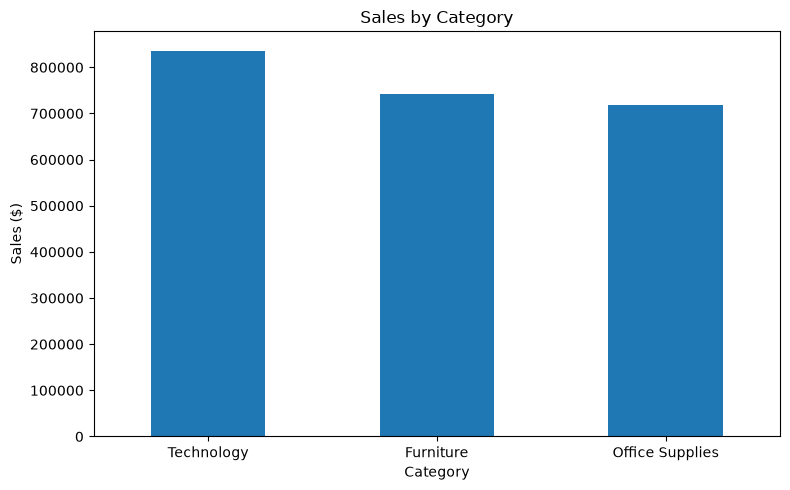

In [15]:
plt.figure(figsize=(8, 5))

sales_by_category.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Insight

Technology generates the highest sales at approximately $836K, followed by Furniture and Office Supplies. Technology is the strongest-performing product category by sales.

In [16]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

sales_by_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

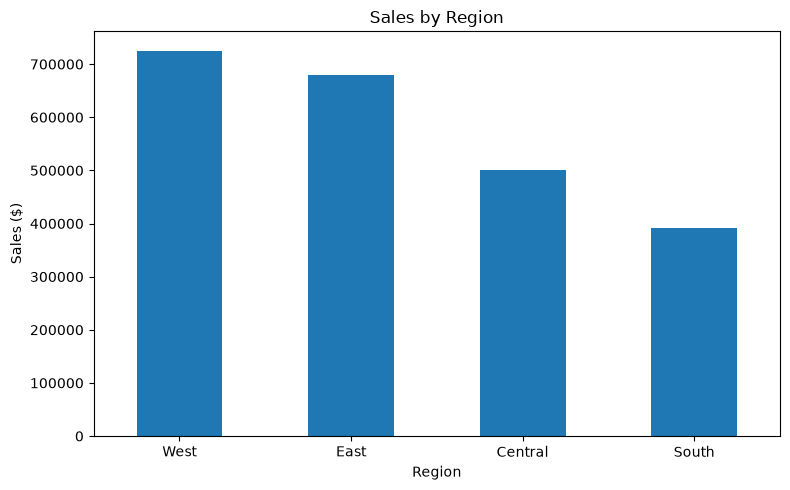

In [17]:
plt.figure(figsize=(8, 5))

sales_by_region.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Insight

The West region generates the highest sales at approximately $725K, while the South region has the lowest sales at approximately $392K.

In [18]:
sales_by_city = (
    df.groupby('City')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sales_by_city

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64

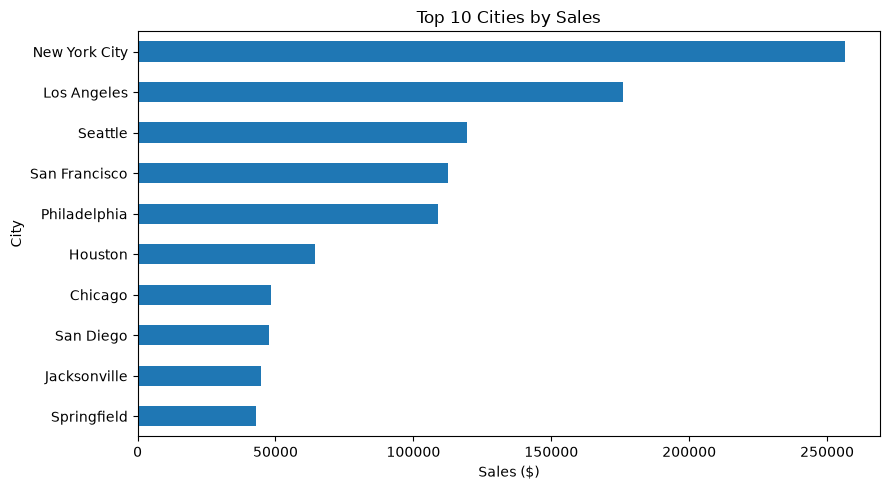

In [19]:
plt.figure(figsize=(9, 5))

sales_by_city.sort_values().plot(kind='barh')

plt.title('Top 10 Cities by Sales')
plt.xlabel('Sales ($)')
plt.ylabel('City')

plt.tight_layout()
plt.show()

### Key Insight

New York City is the strongest-performing city by sales, generating approximately $256K. The top-performing cities are concentrated in major metropolitan markets.

## 4. Profitability Analysis

This section examines the relationship between discounts, quantity, and profit to understand factors that may influence the company's profitability.

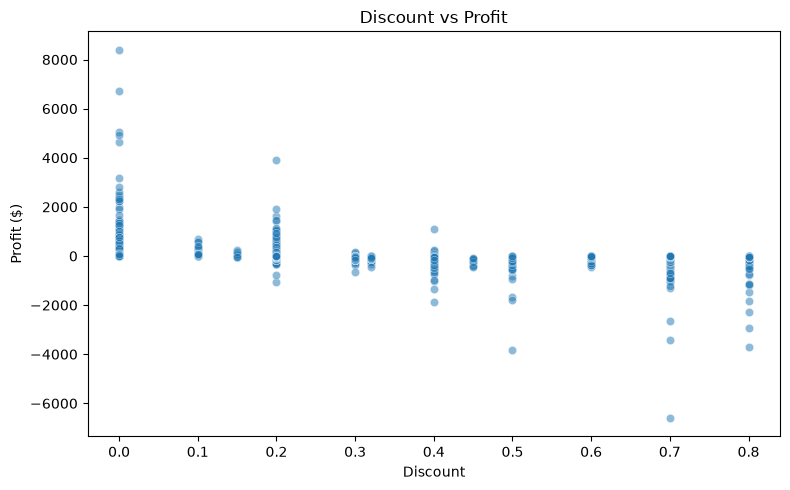

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()

In [21]:
discount_profit = (
    df.groupby('Discount')['Profit']
    .agg(['count', 'mean'])
    .reset_index()
)

discount_profit

,Discount,count,mean
0,0.00,4798,66.900292
1,0.10,94,96.055074
2,0.15,52,27.288298
3,0.20,3657,24.702572
4,0.30,227,-45.679636
5,0.32,27,-88.560656
6,0.40,206,-111.927429
7,0.45,11,-226.646464
8,0.50,66,-310.703456
9,0.60,138,-43.077212


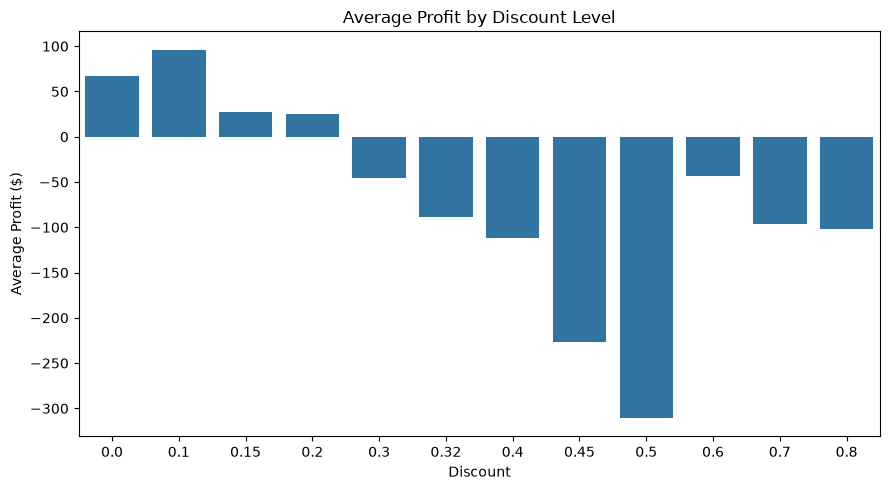

In [22]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=discount_profit,
    x='Discount',
    y='mean'
)

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit ($)')

plt.tight_layout()
plt.show()

### Key Insight

Higher discounts are generally associated with lower profitability. Discounts of 30% or more result in negative average profit in this dataset, while lower discount levels generally maintain positive average profit.

In [23]:
order_summary = df.groupby('Order ID')[['Quantity', 'Profit']].sum()

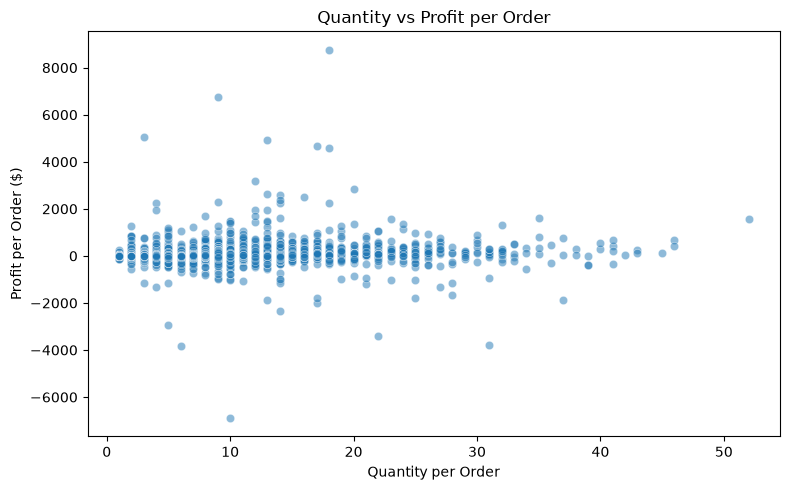

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=order_summary,
    x='Quantity',
    y='Profit',
    alpha=0.5
)

plt.title('Quantity vs Profit per Order')
plt.xlabel('Quantity per Order')
plt.ylabel('Profit per Order ($)')

plt.tight_layout()
plt.show()

### Key Insight

Quantity has a weak positive relationship with profit at the order level, with a correlation of approximately 0.12. This suggests that larger orders tend to be slightly more profitable, but quantity alone is not a strong predictor of profit.

## 5. Customer & Segment Analysis

This section examines sales performance across individual customers and customer segments to identify the most valuable customer groups.

In [25]:
sales_by_customer = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_by_customer.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

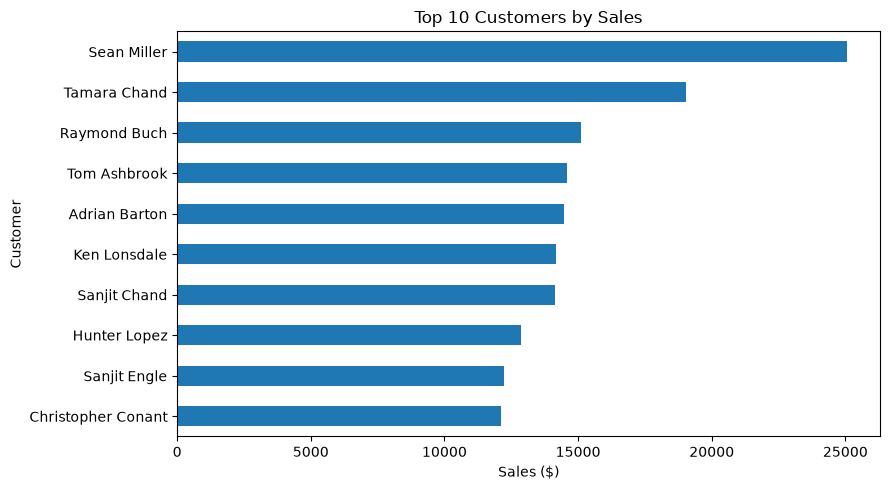

In [26]:
plt.figure(figsize=(9, 5))

sales_by_customer.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Customer')

plt.tight_layout()
plt.show()

### Key Insight

Sean Miller is the highest-selling customer, generating approximately $25K in sales. The top customers represent a relatively small group of high-value accounts that may be important for customer retention strategies.

In [27]:
sales_by_segment = (
    df.groupby('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_by_segment

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

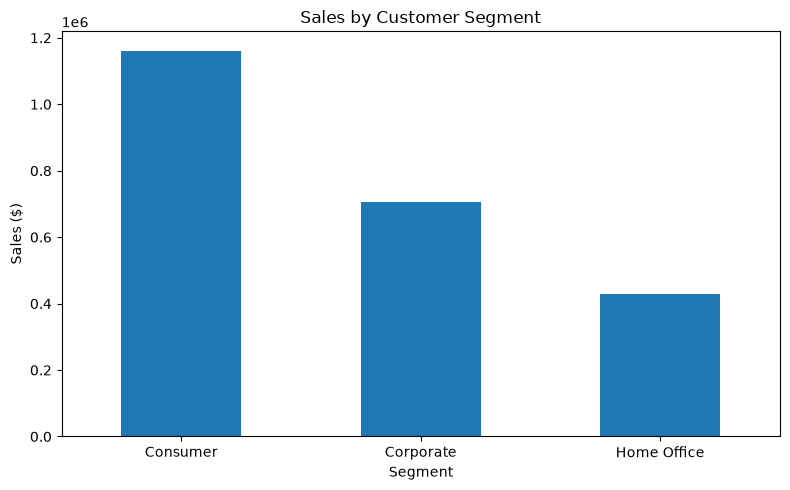

In [28]:
plt.figure(figsize=(8, 5))

sales_by_segment.plot(kind='bar')

plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Insight

The Consumer segment generates the highest sales at approximately $1.16M, significantly outperforming the Corporate and Home Office segments.

## 6. Time Analysis

This section examines sales trends over time and order activity across different days of the week.

In [29]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
    .sum()
)

monthly_sales

Order Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


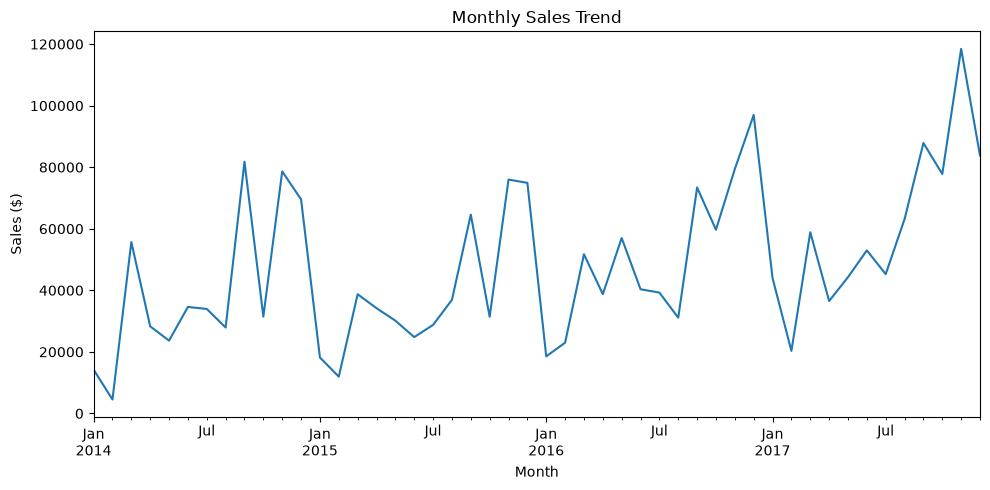

In [30]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind='line')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')

plt.tight_layout()
plt.show()

In [31]:
orders_by_day = (
    df.groupby(df['Order Date'].dt.day_name())['Order ID']
    .nunique()
)

In [32]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

orders_by_day = orders_by_day.reindex(day_order)

orders_by_day

Order Date
Monday       920
Tuesday      558
Wednesday    182
Thursday     746
Friday       916
Saturday     837
Sunday       850
Name: Order ID, dtype: int64

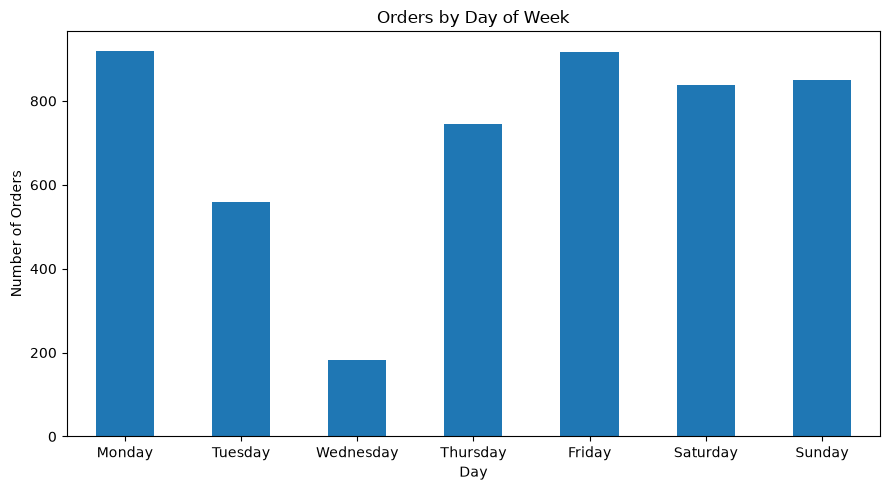

In [33]:
plt.figure(figsize=(9, 5))

orders_by_day.plot(kind='bar')

plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Insights

Sales fluctuate across the four-year period, with noticeable variation between months.

Friday has the highest average order activity among the available dates, while Wednesday has the lowest. However, Wednesday has fewer dates represented in the dataset, so its lower order count should be interpreted cautiously.

## 7. Key Findings

The analysis revealed the following key business insights:

- **Technology leads sales:** Technology generated approximately $836K in sales, making it the highest-performing product category.

- **Regional performance varies:** The West region generated the highest sales at approximately $725K, while the South generated the lowest at approximately $392K.

- **Discounts affect profitability:** Higher discount levels are associated with lower profitability. Discounts of 30% or more resulted in negative average profit in the dataset.

- **Quantity has limited impact on profit:** Quantity and profit showed only a weak positive relationship at the order level, with a correlation of approximately 0.12.

- **Consumer segment dominates:** The Consumer segment generated approximately $1.16M in sales, significantly more than Corporate and Home Office.

- **Customer concentration:** Sean Miller was the highest-selling customer, generating approximately $25K in sales.

- **Order activity varies by day:** Friday had the highest average order activity among the available dates, while Wednesday had the lowest. Wednesday had fewer dates represented in the dataset, so this result should be interpreted cautiously.

## 8. Business Recommendations

Based on the analysis, the following recommendations could help improve sales performance and profitability:

1. **Review high discount levels:** Discounts of 30% or more were associated with negative average profit. The business should review high-discount orders and consider setting discount limits or requiring approval for larger discounts.

2. **Focus on high-performing categories:** Technology generated the highest sales. The business could maintain strong inventory availability and marketing efforts for high-performing Technology products while investigating opportunities to improve weaker categories.

3. **Investigate regional performance:** The South region generated substantially lower sales than the West and East. Further analysis of customer demand, product mix, pricing, and market coverage in the South could identify opportunities for growth.

4. **Strengthen customer retention:** High-value customers such as Sean Miller contribute significant sales. The business could use targeted retention strategies for valuable customers while identifying similar customer profiles for acquisition.